# 📈 Quantitative Multi-Stock Pattern Trading System
### NSE Intraday Backtest — AngelOne SmartAPI
**Features:** 6 candlestick patterns · 6 technical indicators · Realistic transaction costs · Full performance tearsheet

---
| Cell | What it does |
|------|-------------|
| 1 | Install & import libraries |
| 2 | AngelOne SmartAPI authentication |
| 3 | Trading configuration |
| 4 | Transaction cost constants (NSE FY24-25) |
| 5 | Technical indicator functions (RSI, MACD, Bollinger Bands, VWAP) |
| 6 | Candlestick pattern detectors (6 patterns, 10 signals) |
| 7 | Data fetching — `fetch_candles()` |
| 8 | Pattern dispatcher — `detect_all_patterns()` |
| 9 | Cost calculator — `compute_trade_costs()` |
| 10 | Backtest engine — `backtest()` |
| 11 | Fetch data & run backtest |
| 12 | Advanced metrics — `compute_advanced_metrics()` |
| 13 | Full performance tearsheet |

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install & Import Libraries                        ║
# ║  Run once. Restart kernel if SmartApi is newly installed.   ║
# ╚══════════════════════════════════════════════════════════════╝

# Uncomment the line below if SmartApi is not yet installed
# !pip install smartapi-python pyotp logzero

import os
import pyotp                          # Time-based OTP for AngelOne 2FA
import datetime as dt                 # Date/time manipulation
import pandas as pd                   # DataFrames & time-series
import numpy as np                    # Numerical computing
import matplotlib.pyplot as plt       # Plotting
import matplotlib.gridspec as gridspec
import time                           # Rate-limiting between API calls
import warnings
warnings.filterwarnings("ignore")

from SmartApi import SmartConnect     # AngelOne SmartAPI client
from dateutil.relativedelta import relativedelta
from IPython.display import display

%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
pd.set_option("display.max_columns", 30)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — AngelOne SmartAPI Authentication                  ║
# ║  Reads credentials from key.txt                             ║
# ║                                                             ║
# ║  key.txt format (one line, space-separated):                ║
# ║    API_KEY  REFRESH_TOKEN  CLIENT_CODE  PASSWORD  TOTP_SECRET ║
# ╚══════════════════════════════════════════════════════════════╝

# Load credentials from file (never hard-code credentials in notebooks)
with open("key.txt", "r") as f:
    key_secret = f.read().split()

API_KEY      = key_secret[0]
CLIENT_CODE  = key_secret[2]
PASSWORD     = key_secret[3]
TOTP_SECRET  = key_secret[4]

# Initialise SmartConnect with your AngelOne API key
smart_api = SmartConnect(api_key=API_KEY)

try:
    # Generate session — TOTP is computed fresh each call (30-second window)
    data = smart_api.generateSession(
        clientCode = CLIENT_CODE,
        password   = PASSWORD,
        totp       = pyotp.TOTP(TOTP_SECRET).now()
    )

    if data["status"]:
        auth_token   = data["data"]["jwtToken"]
        refresh_token = data["data"]["refreshToken"]
        feed_token   = smart_api.getfeedToken()
        print(f"✅ Login successful  |  Client: {CLIENT_CODE}")
        print(f"   JWT token         : {auth_token[:30]}...")
        print(f"   Feed token        : {feed_token[:20]}...")
    else:
        print(f"❌ Login failed: {data['message']}")

except Exception as e:
    print(f"❌ Authentication error: {e}")

[I 260420 01:26:30 smartConnect:121] in pool


✅ Login successful  |  Client: AAAH659756
   JWT token         : Bearer eyJhbGciOiJIUzUxMiJ9.ey...
   Feed token        : eyJhbGciOiJIUzUxMiJ9...


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Trading & Backtest Configuration                  ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Capital & Risk ────────────────────────────────────────────
CAPITAL       = 300_000   # Starting capital in INR
LEVERAGE      = 5         # Intraday leverage multiplier (5x = MIS margin)
MAX_TRADES    = 2         # Max simultaneous open positions
RISK_PER_TRADE = 0.01     # 1% of current capital risked per trade

# ── Data Settings ─────────────────────────────────────────────
TRADING_DAYS  = 40        # Historical lookback period in calendar days
INTERVAL      = "FIVE_MINUTE"  # Candle interval for AngelOne API
                               # Options: ONE_MINUTE, THREE_MINUTE, FIVE_MINUTE,
                               #          TEN_MINUTE, FIFTEEN_MINUTE, ONE_HOUR, ONE_DAY

# ── Pattern Settings ──────────────────────────────────────────
VOLUME_FILTER = True      # Require increasing volume on 3WS / 3BC patterns

# ── Exit Parameters ───────────────────────────────────────────
ATR_PROFIT_MULT = 1.5     # Profit target = entry ± (ATR_PROFIT_MULT × ATR)
STOP_LOSS_PCT   = 0.01    # 1% fixed stop loss from entry
TRAILING_PCT    = 0.01    # 1% trailing stop from peak/trough
TIME_EXIT_BARS  = 6       # Exit after N candles if no target/stop hit (6 × 5min = 30min)

# ── Stock Universe — 70 NSE stocks across sectors ─────────────
# Format: SYMBOL: {exchange, token}
# Sectors covered: Banking, Defence/PSU, Energy, IT, Infrastructure,
#                  Healthcare, Telecom, FMCG, Real Estate, FinTech
TOKENS = {


    # ========= NIFTY LARGE CAPS =========
    "RELIANCE": {"exchange": "NSE", "token": "2885"},
    "ITC": {"exchange": "NSE", "token": "1660"},
    "HINDUNILVR": {"exchange": "NSE", "token": "1394"},
    "ASIANPAINT": {"exchange": "NSE", "token": "236"},
    "MARUTI": {"exchange": "NSE", "token": "10999"},
    "SUNPHARMA": {"exchange": "NSE", "token": "3351"},
    "ULTRACEMCO": {"exchange": "NSE", "token": "11532"},
    "BAJFINANCE": {"exchange": "NSE", "token": "317"},
    "BAJAJFINSV": {"exchange": "NSE", "token": "16675"},
    "NESTLEIND": {"exchange": "NSE", "token": "17963"},

    # ========= ENERGY =========
    "NTPC": {"exchange": "NSE", "token": "11630"},
    "POWERGRID": {"exchange": "NSE", "token": "14977"},
    "ONGC": {"exchange": "NSE", "token": "2475"},
    "BPCL": {"exchange": "NSE", "token": "526"},
    "IOC": {"exchange": "NSE", "token": "1624"},
    "GAIL": {"exchange": "NSE", "token": "4717"},

    # ========= AUTO =========
    "TATAMOTORS": {"exchange": "NSE", "token": "3456"},
    "EICHERMOT": {"exchange": "NSE", "token": "910"},
    "HEROMOTOCO": {"exchange": "NSE", "token": "1348"},
    "BAJAJ_AUTO": {"exchange": "NSE", "token": "16669"},

    # ========= METALS =========
    "TATASTEEL": {"exchange": "NSE", "token": "3499"},
    "JSWSTEEL": {"exchange": "NSE", "token": "11723"},
    "HINDALCO": {"exchange": "NSE", "token": "1363"},
    "VEDL": {"exchange": "NSE", "token": "3063"},

    # ========= PHARMA =========
    "DRREDDY": {"exchange": "NSE", "token": "881"},
    "CIPLA": {"exchange": "NSE", "token": "694"},
    "DIVISLAB": {"exchange": "NSE", "token": "10940"},
    "ALKEM": {"exchange": "NSE", "token": "11703"},

    # ========= FMCG =========
    "BRITANNIA": {"exchange": "NSE", "token": "547"},
    "DABUR": {"exchange": "NSE", "token": "772"},
    "MARICO": {"exchange": "NSE", "token": "4067"},
    "COLPAL": {"exchange": "NSE", "token": "15141"},

    # ========= NEW AGE / INTERNET =========
    "ZOMATO": {"exchange": "NSE", "token": "5097"},
    "NAUKRI": {"exchange": "NSE", "token": "13751"},
    "PAYTM": {"exchange": "NSE", "token": "6705"},

    # ========= MIDCAP GROWTH =========
    "DIXON": {"exchange": "NSE", "token": "21690"},
    "POLYCAB": {"exchange": "NSE", "token": "9590"},
    "KPITTECH": {"exchange": "NSE", "token": "26000"},
    "TRENT": {"exchange": "NSE", "token": "1964"},
    "TITAN": {"exchange": "NSE", "token": "3506"},

    # ========= DEFENCE =========
    "HAL": {"exchange": "NSE", "token": "2303"},
    # Banking & Finance
    "HDFCBANK":   {"exchange": "NSE", "token": "1330"},
    "ICICIBANK":  {"exchange": "NSE", "token": "11991"},
    "SBIN":       {"exchange": "NSE", "token": "3045"},
    "AXISBANK":   {"exchange": "NSE", "token": "5900"},
    "KOTAKBANK":  {"exchange": "NSE", "token": "1922"},
    "INDUSINDBK": {"exchange": "NSE", "token": "5258"},
    "BANKBARODA": {"exchange": "NSE", "token": "4668"},
    "PNB":        {"exchange": "NSE", "token": "2733"},
    "IDFCFIRSTB": {"exchange": "NSE", "token": "1801"},
    "AUBANK":     {"exchange": "NSE", "token": "17656"},
    "FEDERALBNK": {"exchange": "NSE", "token": "1023"},
    "INDIANB":    {"exchange": "NSE", "token": "14309"},
    "BANKINDIA":  {"exchange": "NSE", "token": "4745"},
    "UNIONBANK":  {"exchange": "NSE", "token": "10753"},
    "BANDHANBNK": {"exchange": "NSE", "token": "2263"},
    "RBLBANK":    {"exchange": "NSE", "token": "18391"},
    # NBFC & FinTech
    "JIOFIN":     {"exchange": "NSE", "token": "18143"},
    "PBFINTECH":  {"exchange": "NSE", "token": "6656"},
    "CGCL":       {"exchange": "NSE", "token": "20329"},
    "PAYTM":      {"exchange": "NSE", "token": "6705"},
    # Infrastructure & PSU
    "RVNL":       {"exchange": "NSE", "token": "9552"},
    "IRFC":       {"exchange": "NSE", "token": "2029"},
    "IRCON":      {"exchange": "NSE", "token": "4986"},
    "IRCTC":      {"exchange": "NSE", "token": "13611"},
    "RECLTD":     {"exchange": "NSE", "token": "15355"},
    "NBCC":       {"exchange": "NSE", "token": "31415"},
    "TITAGARH":   {"exchange": "NSE", "token": "15414"},
    "GRSE":       {"exchange": "NSE", "token": "5475"},
    "MAZDOCK":    {"exchange": "NSE", "token": "509"},
    "RITES":      {"exchange": "NSE", "token": "3761"},
    # Defence
    "BEL":        {"exchange": "NSE", "token": "383"},
    "BDL":        {"exchange": "NSE", "token": "2144"},
    "ITI":        {"exchange": "NSE", "token": "1675"},
    "ASTRAMICRO": {"exchange": "NSE", "token": "11618"},
    # Energy & Power
    "ADANIGREEN": {"exchange": "NSE", "token": "3563"},
    "ADANIPORTS": {"exchange": "NSE", "token": "15083"},
    "SUZLON":     {"exchange": "NSE", "token": "12018"},
    "WAAREEENER": {"exchange": "NSE", "token": "25907"},
    "SJVN":       {"exchange": "NSE", "token": "18883"},
    "CGPOWER":    {"exchange": "NSE", "token": "760"},
    "ATGL":       {"exchange": "NSE", "token": "6066"},
    "PETRONET":   {"exchange": "NSE", "token": "11351"},
    "IGL":        {"exchange": "NSE", "token": "11262"},
    # IT & Telecom
    "INFY":       {"exchange": "NSE", "token": "1594"},
    "HCLTECH":    {"exchange": "NSE", "token": "7229"},
    "BHARTIARTL": {"exchange": "NSE", "token": "10604"},
    "BHARTIHEXA": {"exchange": "NSE", "token": "23489"},
    "TEJASNET":   {"exchange": "NSE", "token": "21131"},
    "INDUSTOWER": {"exchange": "NSE", "token": "29135"},
    "HFCL":       {"exchange": "NSE", "token": "21951"},
    # Healthcare
    "APOLLO":     {"exchange": "NSE", "token": "1134"},
    "FORTIS":     {"exchange": "NSE", "token": "14592"},
    "MAXHEALTH":  {"exchange": "NSE", "token": "22377"},
    "LUPIN":      {"exchange": "NSE", "token": "10440"},
    # Manufacturing & Industrials
    "SIEMENS":    {"exchange": "NSE", "token": "3150"},
    "VOLTAS":     {"exchange": "NSE", "token": "3718"},
    "LUMAXTECH":  {"exchange": "NSE", "token": "14014"},
    "WELCORP":    {"exchange": "NSE", "token": "11821"},
    "AEROFLEX":   {"exchange": "NSE", "token": "18268"},
    # Others
    "IFCI":       {"exchange": "NSE", "token": "1491"},
    "MMTC":       {"exchange": "NSE", "token": "17957"},
    "NAZARA":     {"exchange": "NSE", "token": "2987"},
    "LTFOODS":    {"exchange": "NSE", "token": "13816"},
    "BSE":        {"exchange": "NSE", "token": "19585"},
    "AZAD":       {"exchange": "NSE", "token": "20905"},
    "HUBTOWN":    {"exchange": "NSE", "token": "14203"},
    "JUBLFOOD":   {"exchange": "NSE", "token": "18096"},
    "PBFINTECH":  {"exchange": "NSE", "token": "6656"},
    "SJVN":       {"exchange": "NSE", "token": "18883"},
    "VMM":        {"exchange": "NSE", "token": "27969"},
}

print(f"✅ Configuration loaded  |  Capital: ₹{CAPITAL:,}  |  Leverage: {LEVERAGE}x  |  Stocks: {len(TOKENS)}")
print(f"   Lookback: {TRADING_DAYS} days  |  Interval: {INTERVAL}  |  Max concurrent trades: {MAX_TRADES}")

✅ Configuration loaded  |  Capital: ₹300,000  |  Leverage: 5x  |  Stocks: 68
   Lookback: 40 days  |  Interval: FIVE_MINUTE  |  Max concurrent trades: 2


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — NSE Transaction Cost Constants  (FY 2024-25)      ║
# ║  Source: NSE circular, SEBI circular, AngelOne fee schedule  ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Brokerage (AngelOne flat-fee model) ───────────────────────
BROKERAGE_FLAT   = 20        # ₹20 flat per order leg
BROKERAGE_MAX_PCT = 0.0003   # 0.03% cap — lower of flat vs % is charged

# ── Securities Transaction Tax (STT) ─────────────────────────
# Intraday equity: 0.025% on SELL side only (not both legs)
STT_SELL_PCT     = 0.00025

# ── NSE Exchange Transaction Charge ──────────────────────────
NSE_TXN_PCT      = 0.0000335  # 0.00335% per side on turnover

# ── SEBI Turnover Fee + IPFT ──────────────────────────────────
SEBI_FEE_PCT     = 0.000001   # ₹10 per crore
IPFT_PCT         = 0.0000001  # ₹1 per crore (Investor Protection Fund)

# ── Stamp Duty ────────────────────────────────────────────────
STAMP_DUTY_PCT   = 0.00003    # 0.003% on BUY side only
STAMP_DUTY_CAP   = 1500       # ₹1,500 maximum per instrument

# ── GST ───────────────────────────────────────────────────────
GST_PCT          = 0.18       # 18% on brokerage + NSE charge + SEBI fee
                               # NOT applied on STT or stamp duty

# ── Slippage (market impact + bid-ask spread) ─────────────────
SLIPPAGE_PCT     = 0.0005     # 0.05% per side — reasonable for Nifty 500
                               # Use 0.001 for small/mid-cap illiquid stocks

print("✅ Cost constants loaded")
print(f"   Brokerage: ₹{BROKERAGE_FLAT} flat or {BROKERAGE_MAX_PCT*100:.3f}% (whichever is lower)")
print(f"   STT: {STT_SELL_PCT*100:.4f}% sell-side | Slippage: {SLIPPAGE_PCT*100:.3f}% per side")
print(f"   Typical round-trip cost: ~{(STT_SELL_PCT + 2*NSE_TXN_PCT + STAMP_DUTY_PCT + 2*SLIPPAGE_PCT)*100:.3f}% of trade value")

✅ Cost constants loaded
   Brokerage: ₹20 flat or 0.030% (whichever is lower)
   STT: 0.0250% sell-side | Slippage: 0.050% per side
   Typical round-trip cost: ~0.135% of trade value


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Technical Indicator Functions                     ║
# ║  RSI · MACD · Bollinger Bands · VWAP · MA20 · ATR          ║
# ╚══════════════════════════════════════════════════════════════╝

def compute_rsi(series, period=14):
    """Relative Strength Index (0–100). Above 70 = overbought, below 30 = oversold."""
    delta = series.diff()
    gain  = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))


def compute_macd(series, fast=12, slow=26, signal=9):
    """
    MACD — momentum indicator comparing two EMAs.
    Returns DataFrame with: MACD, MACD_Sig, MACD_Hist.
    MACD > MACD_Sig → bullish momentum. MACD < MACD_Sig → bearish.
    """
    ema_fast    = series.ewm(span=fast,   adjust=False).mean()
    ema_slow    = series.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return pd.DataFrame({"MACD": macd_line, "MACD_Sig": signal_line, "MACD_Hist": histogram},
                        index=series.index)


def compute_bollinger_bands(series, period=20, std_dev=2):
    """
    Bollinger Bands — volatility envelope around SMA.
    Returns: BB_Mid, BB_Upper, BB_Lower, BB_Width (squeeze), BB_Pct (%B, 0=lower 1=upper).
    BB_Pct < 0.1 → price near lower band (oversold zone).
    BB_Pct > 0.9 → price near upper band (overbought zone).
    """
    sma   = series.rolling(window=period).mean()
    std   = series.rolling(window=period).std()
    upper = sma + std_dev * std
    lower = sma - std_dev * std
    return pd.DataFrame({
        "BB_Mid":   sma,
        "BB_Upper": upper,
        "BB_Lower": lower,
        "BB_Width": (upper - lower) / sma,          # squeeze indicator
        "BB_Pct":   (series - lower) / (upper - lower),  # %B
    }, index=series.index)


def compute_vwap(df):
    """
    Session-reset VWAP with ±1σ and ±2σ bands.
    CRITICAL: resets each trading day at 9:15 AM — must group by date.
    Price above VWAP → bullish intraday bias (institutions buying).
    Price below VWAP → bearish intraday bias.
    """
    df       = df.copy()
    df["_tp"]    = (df["high"] + df["low"] + df["close"]) / 3  # typical price
    df["_tpvol"] = df["_tp"] * df["volume"]
    df["_date"]  = df.index.date

    results = {"VWAP": [], "VWAP_Std1U": [], "VWAP_Std1L": [],
               "VWAP_Std2U": [], "VWAP_Std2L": []}
    indices  = []

    for date, grp in df.groupby("_date"):
        cum_tpvol = grp["_tpvol"].cumsum()
        cum_vol   = grp["volume"].cumsum()
        vwap      = cum_tpvol / cum_vol
        cum_sq    = ((grp["_tp"] - vwap) ** 2 * grp["volume"]).cumsum()
        std       = (cum_sq / cum_vol).apply(lambda x: x ** 0.5)

        indices.extend(grp.index.tolist())
        results["VWAP"].extend(vwap.tolist())
        results["VWAP_Std1U"].extend((vwap + 1 * std).tolist())
        results["VWAP_Std1L"].extend((vwap - 1 * std).tolist())
        results["VWAP_Std2U"].extend((vwap + 2 * std).tolist())
        results["VWAP_Std2L"].extend((vwap - 2 * std).tolist())

    df.drop(columns=["_tp", "_tpvol", "_date"], inplace=True)
    return pd.DataFrame(results, index=indices)


print("✅ Indicator functions defined: RSI · MACD · Bollinger Bands · VWAP")

✅ Indicator functions defined: RSI · MACD · Bollinger Bands · VWAP


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Candlestick Pattern Detectors                     ║
# ║  6 patterns → 10 boolean signals (5 bullish, 5 bearish)     ║
# ╚══════════════════════════════════════════════════════════════╝

# ──────────────────────────────────────────────────────────────
# PATTERN 1 & 2 — Three White Soldiers (bullish) & Three Black Crows (bearish)
# 3-candle patterns showing sustained directional momentum with volume
# ──────────────────────────────────────────────────────────────
def detect_three_candle_patterns(df):
    """Detects 3WS (bullish) and 3BC (bearish). Adds columns: 3WS, 3BC."""
    df["3WS"] = False
    df["3BC"] = False
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]

        # Three White Soldiers: 3 consecutive bullish candles, each higher open+close
        tws_conds = [
            c1["close"] > c1["open"] * 1.002,
            c2["close"] > c2["open"] * 1.002,
            c3["close"] > c3["open"] * 1.002,
            c2["open"]  > c1["open"],
            c3["open"]  > c2["open"],
            c2["close"] > c1["close"],
            c3["close"] > c2["close"],
        ]
        if VOLUME_FILTER:
            tws_conds.append(c1["volume"] < c2["volume"] < c3["volume"])
        if all(tws_conds):
            df.at[df.index[i], "3WS"] = True

        # Three Black Crows: 3 consecutive bearish candles, each lower open+close
        tbc_conds = [
            c1["close"] < c1["open"] * 0.998,
            c2["close"] < c2["open"] * 0.998,
            c3["close"] < c3["open"] * 0.998,
            c2["open"]  < c1["open"],
            c3["open"]  < c2["open"],
            c2["close"] < c1["close"],
            c3["close"] < c2["close"],
        ]
        if VOLUME_FILTER:
            tbc_conds.append(c1["volume"] < c2["volume"] < c3["volume"])
        if all(tbc_conds):
            df.at[df.index[i], "3BC"] = True
    return df


# ──────────────────────────────────────────────────────────────
# PATTERN 3 — Hammer (bullish) & Shooting Star (bearish)
# Single-candle reversal: long shadow shows price rejection
# ──────────────────────────────────────────────────────────────
def detect_hammer_shooting_star(df, min_body_pct=0.002, shadow_ratio=2.0, max_opp_shadow=0.3):
    """
    Hammer: long lower shadow ≥ 2× body, tiny upper shadow → buyers rejected sellers.
    Shooting Star: long upper shadow ≥ 2× body, tiny lower shadow → sellers rejected buyers.
    Adds columns: HAMMER, SHOOTST.
    """
    df["HAMMER"]  = False
    df["SHOOTST"] = False
    for i in range(len(df)):
        c = df.iloc[i]
        body         = abs(c["close"] - c["open"])
        candle_range = c["high"] - c["low"]
        if candle_range == 0 or body < c["close"] * min_body_pct:
            continue
        upper_shadow = c["high"] - max(c["open"], c["close"])
        lower_shadow = min(c["open"], c["close"]) - c["low"]

        if (lower_shadow >= shadow_ratio * body and
                upper_shadow <= max_opp_shadow * body and
                (min(c["open"], c["close"]) - c["low"]) / candle_range >= 0.6):
            df.at[df.index[i], "HAMMER"] = True

        if (upper_shadow >= shadow_ratio * body and
                lower_shadow <= max_opp_shadow * body and
                (c["high"] - max(c["open"], c["close"])) / candle_range >= 0.6):
            df.at[df.index[i], "SHOOTST"] = True
    return df


# ──────────────────────────────────────────────────────────────
# PATTERN 4 — Doji (Standard, Dragonfly bullish, Gravestone bearish)
# Open ≈ Close → indecision. Sub-type gives directional bias.
# ──────────────────────────────────────────────────────────────
def detect_doji(df, body_threshold=0.10, shadow_balance=0.25):
    """
    Standard Doji: body < 10% of range.
    Dragonfly (bullish): long lower shadow, negligible upper.
    Gravestone (bearish): long upper shadow, negligible lower.
    Adds columns: DOJI, DOJI_DRAG, DOJI_GRAV.
    """
    df["DOJI"]      = False
    df["DOJI_DRAG"] = False
    df["DOJI_GRAV"] = False
    for i in range(len(df)):
        c = df.iloc[i]
        candle_range = c["high"] - c["low"]
        if candle_range == 0:
            continue
        body         = abs(c["close"] - c["open"])
        upper_shadow = c["high"] - max(c["open"], c["close"])
        lower_shadow = min(c["open"], c["close"]) - c["low"]

        if body / candle_range > body_threshold:
            continue
        df.at[df.index[i], "DOJI"] = True

        if lower_shadow > 0 and upper_shadow / lower_shadow <= shadow_balance:
            df.at[df.index[i], "DOJI_DRAG"] = True
        elif upper_shadow > 0 and lower_shadow / upper_shadow <= shadow_balance:
            df.at[df.index[i], "DOJI_GRAV"] = True
    return df


# ──────────────────────────────────────────────────────────────
# PATTERN 5 — Bullish & Bearish Engulfing
# 2-candle pattern: second candle body completely wraps first
# ──────────────────────────────────────────────────────────────
def detect_engulfing(df, min_body_pct=0.002, size_ratio=1.0):
    """
    Bullish Engulfing: green body wraps previous red body → buyer takeover.
    Bearish Engulfing: red body wraps previous green body → seller takeover.
    Volume on C2 must exceed C1 for confirmation.
    Adds columns: ENG_BULL, ENG_BEAR.
    """
    df["ENG_BULL"] = False
    df["ENG_BEAR"] = False
    for i in range(1, len(df)):
        c1, c2 = df.iloc[i-1], df.iloc[i]
        body_c1 = abs(c1["close"] - c1["open"])
        body_c2 = abs(c2["close"] - c2["open"])
        if body_c1 < c1["close"] * min_body_pct or body_c2 < c2["close"] * min_body_pct:
            continue
        vol_ok = c2["volume"] >= c1["volume"]

        if (c1["close"] < c1["open"] and c2["close"] > c2["open"] and
                c2["open"] <= c1["close"] and c2["close"] >= c1["open"] and
                body_c2 >= size_ratio * body_c1 and vol_ok):
            df.at[df.index[i], "ENG_BULL"] = True

        if (c1["close"] > c1["open"] and c2["close"] < c2["open"] and
                c2["open"] >= c1["close"] and c2["close"] <= c1["open"] and
                body_c2 >= size_ratio * body_c1 and vol_ok):
            df.at[df.index[i], "ENG_BEAR"] = True
    return df


# ──────────────────────────────────────────────────────────────
# PATTERN 6 — Morning Star (bullish) & Evening Star (bearish)
# 3-candle reversal: large candle → indecision star → reversal candle
# ──────────────────────────────────────────────────────────────
def detect_morning_evening_star(df, large_body_pct=0.004, star_body_pct=0.002, c3_penetration=0.5):
    """
    Morning Star: large bearish → small star → large bullish closing ≥50% into C1.
    Evening Star: large bullish → small star → large bearish closing ≥50% into C1.
    NOTE: On 5-min charts there are no price gaps, so star is identified by small body size.
    Adds columns: MORN_STAR, EVE_STAR.
    """
    df["MORN_STAR"] = False
    df["EVE_STAR"]  = False
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        b1 = abs(c1["close"] - c1["open"])
        b2 = abs(c2["close"] - c2["open"])
        b3 = abs(c3["close"] - c3["open"])

        if (c1["close"] < c1["open"] and b1 >= c1["close"] * large_body_pct and
                b2 <= c2["close"] * star_body_pct and
                c3["close"] > c3["open"] and b3 >= c3["close"] * large_body_pct):
            if c3["close"] >= c1["open"] - b1 * c3_penetration:
                df.at[df.index[i], "MORN_STAR"] = True

        if (c1["close"] > c1["open"] and b1 >= c1["close"] * large_body_pct and
                b2 <= c2["close"] * star_body_pct and
                c3["close"] < c3["open"] and b3 >= c3["close"] * large_body_pct):
            if c3["close"] <= c1["open"] + b1 * c3_penetration:
                df.at[df.index[i], "EVE_STAR"] = True
    return df


# ── Dispatcher: run all 6 detectors ──────────────────────────
def detect_all_patterns(df):
    """Run all pattern detectors. Returns df with 10 new boolean columns."""
    df = detect_three_candle_patterns(df)
    df = detect_hammer_shooting_star(df)
    df = detect_doji(df)
    df = detect_engulfing(df)
    df = detect_morning_evening_star(df)
    return df

print("✅ Pattern detectors defined: 3WS · 3BC · Hammer · Shooting Star · Doji · Engulfing · Morning/Evening Star")
print("   Bullish signals: 3WS, HAMMER, DOJI_DRAG, ENG_BULL, MORN_STAR")
print("   Bearish signals: 3BC, SHOOTST, DOJI_GRAV, ENG_BEAR, EVE_STAR")

✅ Pattern detectors defined: 3WS · 3BC · Hammer · Shooting Star · Doji · Engulfing · Morning/Evening Star
   Bullish signals: 3WS, HAMMER, DOJI_DRAG, ENG_BULL, MORN_STAR
   Bearish signals: 3BC, SHOOTST, DOJI_GRAV, ENG_BEAR, EVE_STAR


In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Data Fetching: fetch_candles()                    ║
# ║  Calls AngelOne getCandleData API and computes all 6        ║
# ║  indicators: MA20, ATR, RSI, MACD, Bollinger Bands, VWAP   ║
# ╚══════════════════════════════════════════════════════════════╝

def fetch_candles(symbol, exchange, token, days=TRADING_DAYS, interval=INTERVAL):
    """
    Fetch OHLCV candlestick data from AngelOne SmartAPI and compute
    all technical indicators in one step.

    Args:
        symbol   : Stock symbol string, e.g. 'INFY'
        exchange : Exchange string, 'NSE' or 'BSE'
        token    : Instrument token (from AngelOne scrip master)
        days     : Historical lookback in calendar days (default TRADING_DAYS)
        interval : Candle interval string (default INTERVAL from config)

    Returns:
        DataFrame indexed by datetime with columns:
        open, high, low, close, volume,
        MA20, ATR, RSI,
        MACD, MACD_Sig, MACD_Hist,
        BB_Mid, BB_Upper, BB_Lower, BB_Width, BB_Pct,
        VWAP, VWAP_Std1U, VWAP_Std1L, VWAP_Std2U, VWAP_Std2L
        Returns empty DataFrame on any failure.
    """
    fromdate = (dt.datetime.now() - relativedelta(days=days)).strftime("%Y-%m-%d 09:15")
    todate   = dt.datetime.now().strftime("%Y-%m-%d %H:%M")

    params = {
        "exchange":    exchange,
        "symboltoken": token,
        "interval":    interval,
        "fromdate":    fromdate,
        "todate":      todate,
    }

    try:
        time.sleep(3)  # AngelOne rate limit: ~1 req/3 sec on historical endpoint
        res = smart_api.getCandleData(params)

        if not (res["status"] and res["data"]):
            print(f"  ⚠️  {symbol}: {res.get('message', 'No data returned')}")
            return pd.DataFrame()

        df = pd.DataFrame(res["data"], columns=["datetime","open","high","low","close","volume"])
        df["datetime"] = pd.to_datetime(df["datetime"])
        df.set_index("datetime", inplace=True)

        # Need ≥26 bars for MACD slow EMA to warm up
        if len(df) < 26:
            print(f"  ⚠️  {symbol}: only {len(df)} bars — skipping (need ≥26)")
            return pd.DataFrame()

        # ── Trend & Volatility Indicators ─────────────────────
        df["MA20"] = df["close"].rolling(window=20).mean()

        # ATR: max of (H-L), |H-prev_C|, |L-prev_C| — measures true range volatility
        df["ATR"] = pd.concat([
            df["high"] - df["low"],
            abs(df["high"] - df["close"].shift()),
            abs(df["low"]  - df["close"].shift()),
        ], axis=1).max(axis=1).rolling(window=14).mean()

        df["RSI"] = compute_rsi(df["close"], 14)

        # ── MACD ──────────────────────────────────────────────
        macd_df = compute_macd(df["close"])
        df = pd.concat([df, macd_df], axis=1)

        # ── Bollinger Bands ───────────────────────────────────
        bb_df = compute_bollinger_bands(df["close"])
        df = pd.concat([df, bb_df], axis=1)

        # ── VWAP (session-reset) ──────────────────────────────
        vwap_df = compute_vwap(df)
        df = pd.concat([df, vwap_df], axis=1)

        return df

    except Exception as e:
        print(f"  ❌ {symbol}: {e}")
        return pd.DataFrame()

print("✅ fetch_candles() defined — fetches OHLCV and computes all 6 indicators per stock")

✅ fetch_candles() defined — fetches OHLCV and computes all 6 indicators per stock


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Pattern Dispatcher: detect_all_patterns()         ║
# ║  Wraps all 6 detectors into a single function call          ║
# ╚══════════════════════════════════════════════════════════════╝

# detect_all_patterns() is already defined in Cell 6.
# This cell is a reference cell — no new code needed.

PATTERN_COLS_BULL = ["3WS", "HAMMER", "DOJI_DRAG", "ENG_BULL", "MORN_STAR"]
PATTERN_COLS_BEAR = ["3BC", "SHOOTST", "DOJI_GRAV", "ENG_BEAR", "EVE_STAR"]
ALL_PATTERN_COLS  = PATTERN_COLS_BULL + PATTERN_COLS_BEAR

# Signal tiers used in entry logic:
#   Tier 1 (strongest): 3WS, 3BC, MORN_STAR, EVE_STAR
#   Tier 2            : ENG_BULL, ENG_BEAR
#   Tier 3            : HAMMER, SHOOTST, DOJI_DRAG, DOJI_GRAV

print("✅ Pattern column reference loaded")
print(f"   Bullish: {PATTERN_COLS_BULL}")
print(f"   Bearish: {PATTERN_COLS_BEAR}")

✅ Pattern column reference loaded
   Bullish: ['3WS', 'HAMMER', 'DOJI_DRAG', 'ENG_BULL', 'MORN_STAR']
   Bearish: ['3BC', 'SHOOTST', 'DOJI_GRAV', 'ENG_BEAR', 'EVE_STAR']


In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Transaction Cost Calculator                       ║
# ║  compute_trade_costs() → itemised dict for one round-trip   ║
# ╚══════════════════════════════════════════════════════════════╝

def compute_trade_costs(entry_price, exit_price, qty, direction="long"):
    """
    Calculate all-in NSE intraday transaction costs for one round-trip trade.

    Includes: Brokerage (both legs) · STT (sell side only) · NSE transaction
    charges (both legs) · SEBI fee + IPFT (both legs) · Stamp duty (buy side
    only) · GST on regulatory charges · Slippage (both legs).

    Args:
        entry_price : Actual entry fill price
        exit_price  : Actual exit fill price
        qty         : Number of shares
        direction   : 'long' or 'short'

    Returns:
        dict with itemised costs and total_cost key.
        Net PnL = Gross PnL - costs['total_cost']
    """
    entry_value = entry_price * qty
    exit_value  = exit_price  * qty

    # Brokerage: ₹20 flat or 0.03% cap, whichever is lower
    brok_entry = min(BROKERAGE_FLAT, BROKERAGE_MAX_PCT * entry_value)
    brok_exit  = min(BROKERAGE_FLAT, BROKERAGE_MAX_PCT * exit_value)

    # STT: sell side only
    # Long  → sell at EXIT   |   Short → sell (open) at ENTRY
    stt = (STT_SELL_PCT * exit_value) if direction == "long" else (STT_SELL_PCT * entry_value)

    # NSE transaction charge: both sides
    nse_entry = NSE_TXN_PCT * entry_value
    nse_exit  = NSE_TXN_PCT * exit_value

    # SEBI + IPFT: both sides
    sebi_entry = (SEBI_FEE_PCT + IPFT_PCT) * entry_value
    sebi_exit  = (SEBI_FEE_PCT + IPFT_PCT) * exit_value

    # Stamp duty: buy side only
    # Long → buy at ENTRY   |   Short → buy-back at EXIT
    stamp = min(STAMP_DUTY_PCT * (entry_value if direction == "long" else exit_value),
                STAMP_DUTY_CAP)

    # GST: 18% on (brokerage + NSE charge + SEBI) — NOT on STT/stamp
    gst_entry = GST_PCT * (brok_entry + nse_entry + sebi_entry)
    gst_exit  = GST_PCT * (brok_exit  + nse_exit  + sebi_exit)

    # Slippage (already baked into fill price, included here for reporting)
    slip_entry = SLIPPAGE_PCT * entry_value
    slip_exit  = SLIPPAGE_PCT * exit_value

    total = (brok_entry + brok_exit + stt + nse_entry + nse_exit +
             sebi_entry + sebi_exit + stamp + gst_entry + gst_exit +
             slip_entry + slip_exit)

    return {
        "brokerage":  round(brok_entry + brok_exit, 2),
        "stt":        round(stt, 2),
        "nse_charge": round(nse_entry + nse_exit, 4),
        "sebi_fee":   round(sebi_entry + sebi_exit, 4),
        "stamp_duty": round(stamp, 2),
        "gst":        round(gst_entry + gst_exit, 2),
        "slippage":   round(slip_entry + slip_exit, 2),
        "total_cost": round(total, 2),
    }

print("✅ compute_trade_costs() defined")
# Quick sanity check: ₹5L long position
_c = compute_trade_costs(500, 510, 1000, "long")
print(f"   Example — ₹5L long: total cost ₹{_c['total_cost']:,.2f}  "
      f"({_c['total_cost']/500000*100:.3f}% of position)")
print(f"   Breakdown → Brokerage ₹{_c['brokerage']} · STT ₹{_c['stt']} · "
      f"Slippage ₹{_c['slippage']} · GST ₹{_c['gst']}")

✅ compute_trade_costs() defined
   Example — ₹5L long: total cost ₹735.94  (0.147% of position)
   Breakdown → Brokerage ₹40 · STT ₹127.5 · Slippage ₹505.0 · GST ₹13.49


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Backtest Engine: backtest()                      ║
# ╚══════════════════════════════════════════════════════════════╝
#
# HOW IT WORKS
# ─────────────────────────────────────────────────────────────
# 1. Synchronise all stock DataFrames onto a common timeline
# 2. For each timestamp, iterate every stock:
#    a. EXIT CHECK (checked before entry to avoid same-bar open+close)
#       Long exits  : Profit Target | Stop Loss | Trailing Stop | Time Exit
#       Short exits : Profit Target | Stop Loss | Trailing Stop | Time Exit
#    b. ENTRY CHECK (if stock not already in a position)
#       5 bullish signals (tiered priority, elif chain)
#       5 bearish signals (tiered priority, elif chain)
#       Each signal has its own indicator confirmation set
# 3. Position sizing: 1% risk per trade, leverage-constrained
# 4. Every exit records Gross PnL and Net PnL (after all costs)
# 5. Returns: trades_df, final_capital, equity_df, concurrent_df
#
# ENTRY SIGNAL TIERS & CONFIRMATIONS
# ────────────────────────────────────────────────────────────
# Tier 1  3WS        close>MA20, close>VWAP, MACD_bull, RSI<70, BB_Pct<0.85
# Tier 1  MORN_STAR  close>VWAP, MACD_bull, RSI<70
# Tier 2  ENG_BULL   close>MA20, close>VWAP, RSI<70, BB_Pct<0.85
# Tier 3  HAMMER     close>VWAP, RSI<40 (oversold), BB_Pct<0.85
# Tier 3  DOJI_DRAG  close>VWAP, RSI<40, BB_Pct<0.25 (near lower band)
# (mirror conditions apply for all bearish signals)

def backtest(all_dfs, capital=CAPITAL, leverage=LEVERAGE, max_trades=MAX_TRADES):
    trades          = []
    current_capital = capital
    open_positions  = {}
    equity_curve    = []
    concurrent_hist = []

    # Merge all timestamps across all stocks into one sorted timeline
    all_timestamps = sorted(set().union(*[df.index for df in all_dfs.values()]))

    for timestamp in all_timestamps:

        # ── Mark-to-market equity ──────────────────────────
        equity = current_capital
        for stk, pos in open_positions.items():
            if timestamp in all_dfs[stk].index:
                p = all_dfs[stk].loc[timestamp, "close"]
                if pos["direction"] == "long":
                    equity += (p - pos["entry_price"]) * pos["qty"]
                else:
                    equity += (pos["entry_price"] - p) * pos["qty"]
        equity_curve.append({"timestamp": timestamp, "equity": equity})
        concurrent_hist.append({"timestamp": timestamp, "open_trades": len(open_positions)})

        for stock, df in all_dfs.items():
            if timestamp not in df.index:
                continue
            idx = df.index.get_loc(timestamp)

            # ════════════════════════════════════════════════
            # EXIT LOGIC
            # ════════════════════════════════════════════════
            if stock in open_positions:
                pos       = open_positions[stock]
                price_now = df.iloc[idx]["close"]
                atr       = df.iloc[idx]["ATR"]
                atr_val   = atr if not pd.isna(atr) else price_now * 0.02

                if pos["direction"] == "long":
                    high_px       = max(pos.get("high_price", pos["entry_price"]), price_now)
                    trailing_stop = high_px * (1 - TRAILING_PCT)
                    stop_loss     = pos["entry_price"] * (1 - STOP_LOSS_PCT)
                    profit_target = pos["entry_price"] + ATR_PROFIT_MULT * atr_val

                    hit = (idx >= pos["index"] + TIME_EXIT_BARS or
                           price_now >= profit_target or
                           price_now <= stop_loss or
                           price_now <= trailing_stop)

                    if hit:
                        # Slippage: long exit fills slightly below close
                        exit_price = price_now * (1 - SLIPPAGE_PCT)
                        gross_pnl  = (exit_price - pos["entry_price"]) * pos["qty"]
                        costs      = compute_trade_costs(pos["entry_price"], exit_price,
                                                         pos["qty"], "long")
                        net_pnl    = gross_pnl - costs["total_cost"]
                        current_capital += net_pnl

                        if   idx >= pos["index"] + TIME_EXIT_BARS: reason = "Timeout"
                        elif price_now >= profit_target:            reason = "Profit Target"
                        elif price_now <= stop_loss:                reason = "Stop Loss"
                        else:                                       reason = "Trailing Stop"

                        trades.append({
                            "Stock": stock, "Direction": "long",
                            "Signal": pos.get("signal", "unknown"),
                            "Entry Time": pos["entry_time"], "Exit Time": timestamp,
                            "Entry": pos["entry_price"], "Exit": round(exit_price, 2),
                            "Qty": pos["qty"],
                            "Gross PnL": round(gross_pnl, 2),
                            "Total Cost": costs["total_cost"],
                            "Brokerage": costs["brokerage"], "STT": costs["stt"],
                            "NSE Charges": costs["nse_charge"],
                            "Stamp Duty": costs["stamp_duty"],
                            "GST": costs["gst"], "Slippage": costs["slippage"],
                            "Net PnL": round(net_pnl, 2),
                            "Trade Duration (min)": round(
                                (timestamp - pos["entry_time"]).total_seconds() / 60, 1),
                            "Reason": reason,
                        })
                        del open_positions[stock]
                    else:
                        pos["high_price"] = high_px

                elif pos["direction"] == "short":
                    low_px        = min(pos.get("low_price", pos["entry_price"]), price_now)
                    trailing_stop = low_px * (1 + TRAILING_PCT)
                    stop_loss     = pos["entry_price"] * (1 + STOP_LOSS_PCT)
                    profit_target = pos["entry_price"] - ATR_PROFIT_MULT * atr_val

                    hit = (idx >= pos["index"] + TIME_EXIT_BARS or
                           price_now <= profit_target or
                           price_now >= stop_loss or
                           price_now >= trailing_stop)

                    if hit:
                        # Slippage: short exit (buy-back) fills slightly above close
                        exit_price = price_now * (1 + SLIPPAGE_PCT)
                        gross_pnl  = (pos["entry_price"] - exit_price) * pos["qty"]
                        costs      = compute_trade_costs(pos["entry_price"], exit_price,
                                                         pos["qty"], "short")
                        net_pnl    = gross_pnl - costs["total_cost"]
                        current_capital += net_pnl

                        if   idx >= pos["index"] + TIME_EXIT_BARS: reason = "Timeout"
                        elif price_now <= profit_target:            reason = "Profit Target"
                        elif price_now >= stop_loss:                reason = "Stop Loss"
                        else:                                       reason = "Trailing Stop"

                        trades.append({
                            "Stock": stock, "Direction": "short",
                            "Signal": pos.get("signal", "unknown"),
                            "Entry Time": pos["entry_time"], "Exit Time": timestamp,
                            "Entry": pos["entry_price"], "Exit": round(exit_price, 2),
                            "Qty": pos["qty"],
                            "Gross PnL": round(gross_pnl, 2),
                            "Total Cost": costs["total_cost"],
                            "Brokerage": costs["brokerage"], "STT": costs["stt"],
                            "NSE Charges": costs["nse_charge"],
                            "Stamp Duty": costs["stamp_duty"],
                            "GST": costs["gst"], "Slippage": costs["slippage"],
                            "Net PnL": round(net_pnl, 2),
                            "Trade Duration (min)": round(
                                (timestamp - pos["entry_time"]).total_seconds() / 60, 1),
                            "Reason": reason,
                        })
                        del open_positions[stock]
                    else:
                        pos["low_price"] = low_px

            # ════════════════════════════════════════════════
            # ENTRY LOGIC
            # ════════════════════════════════════════════════
            if stock not in open_positions and idx >= 26:
                row = df.iloc[idx]

                # Guard: skip warmup bars where any indicator is NaN
                req = ["MA20","ATR","RSI","MACD","MACD_Sig","VWAP","BB_Pct"]
                if any(pd.isna(row.get(c)) for c in req):
                    continue

                # ── Shared indicator snapshots ──────────────
                above_ma20     = row["close"] > row["MA20"]
                below_ma20     = row["close"] < row["MA20"]
                above_vwap     = row["close"] > row["VWAP"]
                below_vwap     = row["close"] < row["VWAP"]
                macd_bull      = row["MACD"] > row["MACD_Sig"]
                macd_bear      = row["MACD"] < row["MACD_Sig"]
                rsi_not_ob     = row["RSI"] < 70
                rsi_not_os     = row["RSI"] > 30
                rsi_oversold   = row["RSI"] < 40
                rsi_overbought = row["RSI"] > 60
                bb_not_high    = row["BB_Pct"] < 0.85
                bb_not_low     = row["BB_Pct"] > 0.15

                direction = None
                signal    = None

                # ── BULLISH ENTRIES (tiered, elif — highest tier wins) ──
                if row["3WS"] and above_ma20 and above_vwap and macd_bull and rsi_not_ob and bb_not_high:
                    direction, signal = "long", "3WS"
                elif row["MORN_STAR"] and above_vwap and macd_bull and rsi_not_ob:
                    direction, signal = "long", "MORN_STAR"
                elif row["ENG_BULL"] and above_ma20 and above_vwap and rsi_not_ob and bb_not_high:
                    direction, signal = "long", "ENG_BULL"
                elif row["HAMMER"] and above_vwap and rsi_oversold and bb_not_high:
                    direction, signal = "long", "HAMMER"
                elif row["DOJI_DRAG"] and above_vwap and rsi_oversold and row["BB_Pct"] < 0.25:
                    direction, signal = "long", "DOJI_DRAG"

                # ── BEARISH ENTRIES ─────────────────────────
                elif row["3BC"] and below_ma20 and below_vwap and macd_bear and rsi_not_os and bb_not_low:
                    direction, signal = "short", "3BC"
                elif row["EVE_STAR"] and below_vwap and macd_bear and rsi_not_os:
                    direction, signal = "short", "EVE_STAR"
                elif row["ENG_BEAR"] and below_ma20 and below_vwap and rsi_not_os and bb_not_low:
                    direction, signal = "short", "ENG_BEAR"
                elif row["SHOOTST"] and below_vwap and rsi_overbought and bb_not_low:
                    direction, signal = "short", "SHOOTST"
                elif row["DOJI_GRAV"] and below_vwap and rsi_overbought and row["BB_Pct"] > 0.75:
                    direction, signal = "short", "DOJI_GRAV"
                else:
                    continue

                # ── Position sizing ──────────────────────────
                # Apply entry slippage to the fill price
                raw_entry = row["open"]
                if direction == "long":
                    entry_price = raw_entry * (1 + SLIPPAGE_PCT)  # fills slightly higher
                else:
                    entry_price = raw_entry * (1 - SLIPPAGE_PCT)  # fills slightly lower

                stop_distance  = entry_price * STOP_LOSS_PCT
                risk_budget    = RISK_PER_TRADE * current_capital
                qty_risk       = int(risk_budget / stop_distance)

                max_pos_value  = leverage * current_capital
                valid_qtys     = [q for q in [100,200,500,1000,2000,3000,4000,5000]
                                  if q * entry_price <= max_pos_value]
                if not valid_qtys:
                    continue

                qty              = min(qty_risk, max(valid_qtys))
                capital_required = (qty * entry_price) / leverage
                capital_in_use   = sum(p["capital_used"] for p in open_positions.values())

                if len(open_positions) >= max_trades or capital_required > (current_capital - capital_in_use):
                    continue

                open_positions[stock] = {
                    "direction":    direction,
                    "signal":       signal,
                    "entry_time":   timestamp,
                    "qty":          qty,
                    "entry_price":  entry_price,
                    "capital_used": capital_required,
                    "index":        idx,
                    "high_price":   entry_price if direction == "long"  else None,
                    "low_price":    entry_price if direction == "short" else None,
                }

    trades_df   = pd.DataFrame(trades)
    equity_df   = pd.DataFrame(equity_curve)
    concurrent_df = pd.DataFrame(concurrent_hist)
    return trades_df, current_capital, equity_df, concurrent_df

print("✅ backtest() engine defined")
print("   Entry signals: 3WS · MORN_STAR · ENG_BULL · HAMMER · DOJI_DRAG (bullish)")
print("                  3BC · EVE_STAR  · ENG_BEAR · SHOOTST · DOJI_GRAV (bearish)")
print("   Exit rules   : Profit Target (1.5×ATR) · Stop Loss (1%) · Trailing Stop · Time Exit (30min)")
print("   Costs        : Brokerage · STT · NSE charges · SEBI fee · Stamp duty · GST · Slippage")

✅ backtest() engine defined
   Entry signals: 3WS · MORN_STAR · ENG_BULL · HAMMER · DOJI_DRAG (bullish)
                  3BC · EVE_STAR  · ENG_BEAR · SHOOTST · DOJI_GRAV (bearish)
   Exit rules   : Profit Target (1.5×ATR) · Stop Loss (1%) · Trailing Stop · Time Exit (30min)
   Costs        : Brokerage · STT · NSE charges · SEBI fee · Stamp duty · GST · Slippage


In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Fetch Data, Detect Patterns, Run Backtest        ║
# ║  ⏱  This cell takes ~4–6 minutes (3-sec delay per stock)    ║
# ╚══════════════════════════════════════════════════════════════╝

print(f"📡 Fetching candles for {len(TOKENS)} stocks...")
print(f"   Interval: {INTERVAL}  |  Lookback: {TRADING_DAYS} days")
print(f"   Estimated time: ~{len(TOKENS)*3//60}–{len(TOKENS)*3//60+2} minutes\n")

all_dfs        = {}
no_data_stocks = []

for i, (stock, info) in enumerate(TOKENS.items(), 1):
    print(f"  [{i:>3}/{len(TOKENS)}] {stock:<14}", end="")
    df = fetch_candles(stock, info["exchange"], info["token"])
    if not df.empty:
        df = detect_all_patterns(df)
        all_dfs[stock] = df

        # Count patterns found for this stock
        bull_count = sum(df[c].sum() for c in PATTERN_COLS_BULL if c in df.columns)
        bear_count = sum(df[c].sum() for c in PATTERN_COLS_BEAR if c in df.columns)
        print(f"  ✅  {len(df):>4} bars  |  bullish signals: {int(bull_count):>3}  |  bearish signals: {int(bear_count):>3}")
    else:
        no_data_stocks.append(stock)
        print(f"  ⚠️  skipped")

print(f"\n{'─'*60}")
print(f"✅ Data loaded: {len(all_dfs)} stocks  |  Skipped: {len(no_data_stocks)}")
if no_data_stocks:
    print(f"   Skipped: {', '.join(no_data_stocks)}")

# Pattern summary across universe
print("\n📊 Pattern occurrence summary across all stocks:")
pat_summary = {}
for col in ALL_PATTERN_COLS:
    pat_summary[col] = int(sum(df[col].sum() for df in all_dfs.values() if col in df.columns))
display(pd.DataFrame([pat_summary]))

# ── Run Backtest ───────────────────────────────────────────────
print("\n🚀 Running backtest engine...")
trades_df, final_capital, equity_df, concurrent_df = backtest(all_dfs)

print(f"\n{'─'*60}")
print(f"✅ Backtest complete")
print(f"   Starting capital : ₹{CAPITAL:>12,.2f}")
print(f"   Final capital    : ₹{final_capital:>12,.2f}")
print(f"   Net return       : ₹{final_capital-CAPITAL:>+12,.2f}  ({(final_capital-CAPITAL)/CAPITAL*100:+.2f}%)")
print(f"   Total trades     : {len(trades_df)}")

if not trades_df.empty:
    print(f"   Gross PnL total  : ₹{trades_df['Gross PnL'].sum():>+12,.2f}")
    print(f"   Net PnL total    : ₹{trades_df['Net PnL'].sum():>+12,.2f}")
    print(f"   Total costs paid : ₹{trades_df['Total Cost'].sum():>12,.2f}")
    print(f"   Win rate (net)   : {(trades_df['Net PnL']>0).mean()*100:.1f}%")

📡 Fetching candles for 68 stocks...
   Interval: FIVE_MINUTE  |  Lookback: 40 days
   Estimated time: ~3–5 minutes

  [  1/68] HDFCBANK        ⚠️  HDFCBANK: SUCCESS
  ⚠️  skipped
  [  2/68] ICICIBANK       ⚠️  ICICIBANK: SUCCESS
  ⚠️  skipped
  [  3/68] SBIN            ✅  1800 bars  |  bullish signals:  38  |  bearish signals:  30
  [  4/68] AXISBANK        ✅  1800 bars  |  bullish signals:  37  |  bearish signals:  24
  [  5/68] KOTAKBANK       ✅  1800 bars  |  bullish signals:  35  |  bearish signals:  23
  [  6/68] INDUSINDBK      ✅  1800 bars  |  bullish signals:  43  |  bearish signals:  38
  [  7/68] BANKBARODA      ✅  1800 bars  |  bullish signals:  33  |  bearish signals:  32
  [  8/68] PNB             ⚠️  PNB: SUCCESS
  ⚠️  skipped
  [  9/68] IDFCFIRSTB      ⚠️  IDFCFIRSTB: SUCCESS
  ⚠️  skipped
  [ 10/68] AUBANK          ✅  1780 bars  |  bullish signals:  94  |  bearish signals:  79
  [ 11/68] FEDERALBNK      ✅  1800 bars  |  bullish signals:  42  |  bearish signals:  21
  [ 

,3WS,HAMMER,DOJI_DRAG,ENG_BULL,MORN_STAR,3BC,SHOOTST,DOJI_GRAV,ENG_BEAR,EVE_STAR
0,226,102,2188,430,144,142,113,1855,383,178



🚀 Running backtest engine...

────────────────────────────────────────────────────────────
✅ Backtest complete
   Starting capital : ₹  300,000.00
   Final capital    : ₹  441,691.06
   Net return       : ₹ +141,691.06  (+47.23%)
   Total trades     : 253
   Gross PnL total  : ₹ +277,955.75
   Net PnL total    : ₹ +141,691.13
   Total costs paid : ₹  136,264.62
   Win rate (net)   : 58.9%


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Advanced Performance Metrics                     ║
# ║  Sortino · Calmar · Profit Factor · Win/Loss Ratio          ║
# ╚══════════════════════════════════════════════════════════════╝

def compute_advanced_metrics(trades_df, equity_df, capital=CAPITAL, tdays=252):
    """
    Compute a full set of professional performance metrics.

    Metrics returned:
      Primary   : Sortino Ratio, Calmar Ratio, Profit Factor, Avg Win/Loss Ratio
      Supporting: Sharpe Ratio, Win Rate, Breakeven Win Rate, Expectancy,
                  Avg Win, Avg Loss, Best/Worst Trade, Max Drawdown,
                  Annualised Return, trade counts

    Args:
        trades_df : Completed trades DataFrame (must have 'Net PnL')
        equity_df : Equity curve DataFrame (columns: timestamp, equity)
        capital   : Starting capital (for return calculation)
        tdays     : Trading days per year for annualisation (default 252)

    Returns: dict — pass to pd.DataFrame([result]).T for display
    """
    if trades_df.empty:
        return {}

    pnl     = trades_df["Net PnL"]
    winners = pnl[pnl > 0]
    losers  = pnl[pnl < 0]

    # ── Sortino Ratio ──────────────────────────────────────────
    # Only penalises downside volatility (unlike Sharpe which penalises all vol)
    mean_pnl     = pnl.mean()
    down_std     = losers.std()
    sortino = (mean_pnl / down_std * np.sqrt(tdays)) if (down_std and not pd.isna(down_std)) else np.nan

    # ── Calmar Ratio ───────────────────────────────────────────
    # Annualised return ÷ max drawdown — measures return per unit of pain
    final_eq     = equity_df["equity"].iloc[-1]
    total_ret    = (final_eq - capital) / capital * 100
    date_range   = (equity_df["timestamp"].iloc[-1] - equity_df["timestamp"].iloc[0]).days
    ann_ret      = total_ret * (365 / date_range) if date_range > 0 else total_ret
    roll_max     = equity_df["equity"].cummax()
    dd_pct       = ((roll_max - equity_df["equity"]) / roll_max * 100)
    max_dd       = dd_pct.max()
    calmar       = ann_ret / max_dd if max_dd > 0 else np.nan

    # ── Profit Factor ──────────────────────────────────────────
    # Gross wins ÷ |gross losses| — below 1.0 = guaranteed to lose
    gross_wins   = winners.sum()
    gross_losses = abs(losers.sum())
    pf           = gross_wins / gross_losses if gross_losses > 0 else np.nan

    # ── Avg Win / Avg Loss ────────────────────────────────────
    # Realised reward-to-risk after costs (should exceed 1.0)
    avg_win  = winners.mean() if not winners.empty else 0
    avg_loss = abs(losers.mean()) if not losers.empty else 0
    wl_ratio = avg_win / avg_loss if avg_loss > 0 else np.nan

    # ── Supporting ────────────────────────────────────────────
    win_rate   = len(winners) / len(pnl) * 100
    sharpe     = (mean_pnl / pnl.std() * np.sqrt(tdays)) if pnl.std() != 0 else np.nan
    # Breakeven win rate: minimum win% needed to be profitable given current avg win/loss
    be_wr      = avg_loss / (avg_win + avg_loss) * 100 if (avg_win + avg_loss) > 0 else np.nan
    # Expectancy: average ₹ expected per trade
    expectancy = win_rate/100 * avg_win - (1 - win_rate/100) * avg_loss

    # Cost erosion
    gross_total = trades_df["Gross PnL"].sum()
    net_total   = trades_df["Net PnL"].sum()
    cost_erosion = (gross_total - net_total) / abs(gross_total) * 100 if gross_total != 0 else 0
    flipped      = int((trades_df["Gross PnL"] > 0).sum() - (trades_df["Net PnL"] > 0).sum())

    return {
        # Primary
        "Sortino Ratio":          round(sortino, 3)  if not pd.isna(sortino) else "N/A",
        "Calmar Ratio":           round(calmar, 3)   if not pd.isna(calmar)  else "N/A",
        "Profit Factor":          round(pf, 3)       if not pd.isna(pf)      else "N/A",
        "Avg Win / Avg Loss":     round(wl_ratio, 3) if not pd.isna(wl_ratio) else "N/A",
        # Risk-adjusted
        "Sharpe Ratio":           round(sharpe, 3)   if not pd.isna(sharpe)  else "N/A",
        "Max Drawdown (%)":       round(max_dd, 2),
        "Annualised Return (%)":  round(ann_ret, 2),
        # Trade quality
        "Win Rate (%)":           round(win_rate, 1),
        "Breakeven Win Rate (%)": round(be_wr, 1)    if not pd.isna(be_wr)   else "N/A",
        "Expectancy (₹/trade)":   round(expectancy, 2),
        "Avg Win (₹)":            round(avg_win, 2),
        "Avg Loss (₹)":           round(avg_loss, 2),
        "Best Trade (₹)":         round(pnl.max(), 2),
        "Worst Trade (₹)":        round(pnl.min(), 2),
        # Cost analysis
        "Cost Erosion (%)":       round(cost_erosion, 1),
        "Trades Flipped by Cost": flipped,
        # Counts
        "Total Trades":           len(pnl),
        "Winners":                len(winners),
        "Losers":                 len(losers),
    }

print("✅ compute_advanced_metrics() defined")
print("   Metrics: Sortino · Calmar · Profit Factor · Win/Loss Ratio · Sharpe")
print("            Expectancy · Breakeven Win Rate · Cost Erosion · Flipped Trades")

✅ compute_advanced_metrics() defined
   Metrics: Sortino · Calmar · Profit Factor · Win/Loss Ratio · Sharpe
            Expectancy · Breakeven Win Rate · Cost Erosion · Flipped Trades


  FULL PERFORMANCE TEARSHEET  —  Net PnL after all transaction costs

  ── Primary metrics ──


,Value
Sortino Ratio,3.67
Calmar Ratio,55.02
Profit Factor,1.59
Avg Win / Avg Loss,1.11
Sharpe Ratio,2.63
Win Rate (%),58.90
Breakeven Win Rate (%),47.40
Expectancy (₹/trade),560.04



  ── Risk & cost metrics ──


,Value
Max Drawdown (%),8.47
Annualised Return (%),465.84
Cost Erosion (%),49.00
Trades Flipped by Cost,17.00
Avg Win (₹),2555.16
Avg Loss (₹),2298.34
Best Trade (₹),13826.43
Worst Trade (₹),-18211.43
Total Trades,253.00
Winners,149.00



  ── Metric interpretation ──
  Sortino Ratio                  3.665   🟢 Excellent   (↑ higher · penalises only losses)
  Calmar Ratio                   55.02   🟢 Excellent   (↑ higher · return per drawdown unit)
  Profit Factor                  1.593   🟡 Good   (↑ higher · <1.0 means losing strategy)
  Avg Win / Avg Loss             1.112   🔴 Needs work   (↑ higher · <1.0 means structurally broken)

  ── Transaction cost breakdown ──
  Component               ₹ Total    % of Gross PnL   ₹ per trade
  ────────────────────────────────────────────────────────────────
  Brokerage          ₹ 10,120.00             3.64%  ₹     40.00
  STT                ₹ 22,854.98             8.22%  ₹     90.34
  NSE Charges        ₹  6,115.78             2.20%  ₹     24.17
  Stamp Duty         ₹  2,734.26             0.98%  ₹     10.81
  GST                ₹  2,958.59             1.06%  ₹     11.69
  Slippage           ₹ 91,280.27            32.84%  ₹    360.79
  ─────────────────────────────────────────

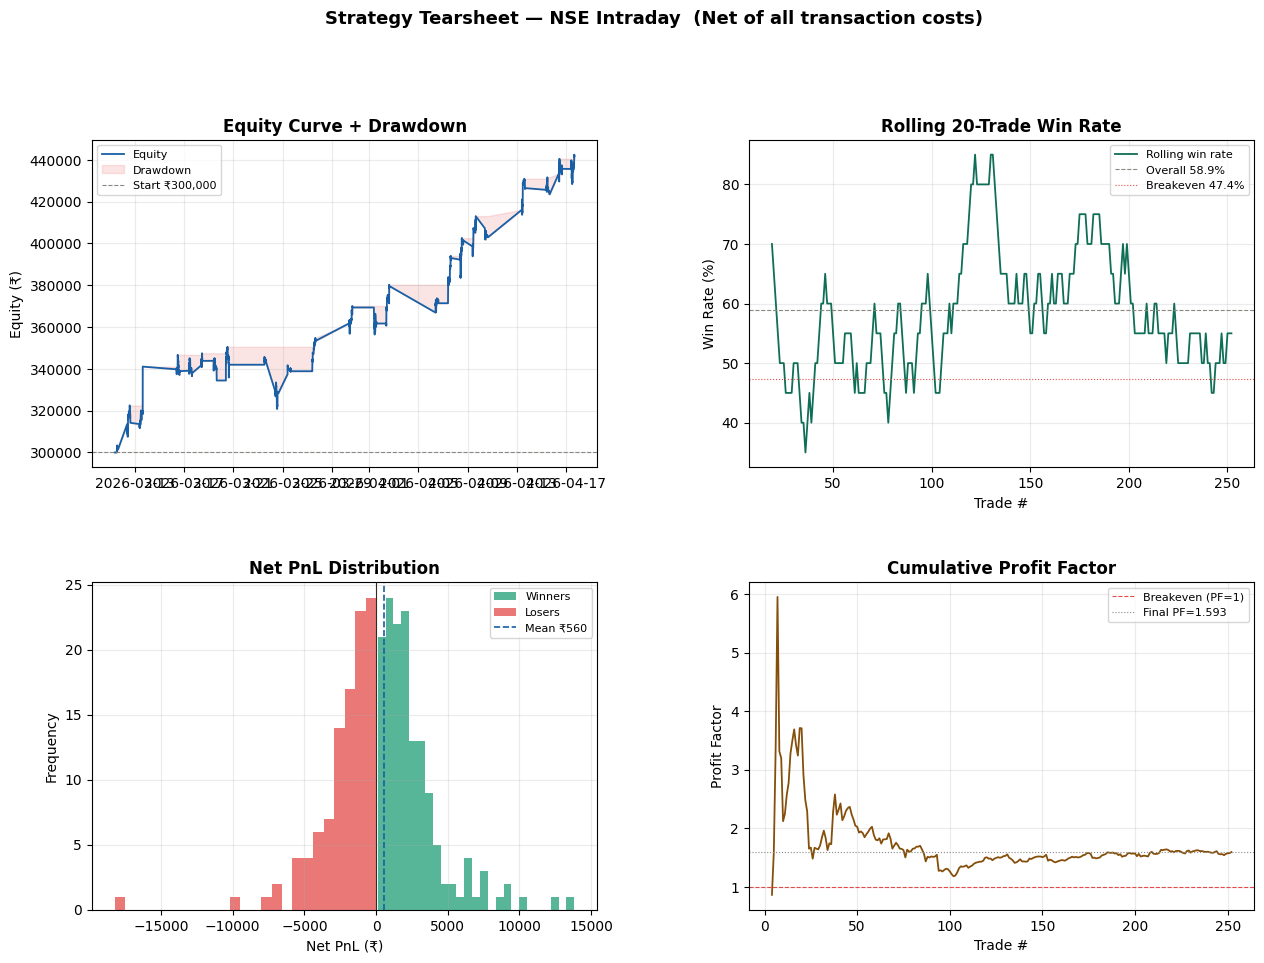


  ── Long vs Short breakdown ──


,Trades,Net PnL (₹),Win Rate,Avg Win (₹),Avg Loss (₹),Profit Factor,Total Costs (₹)
Direction,,,,,,,
long,125,91586.83,57.6%,2841.75,-2132.44,1.81,67452.33
short,128,50104.30,60.2%,2287.17,-2470.74,1.40,68812.29



  ── Per-signal breakdown ──


,Trades,Net PnL (₹),Win Rate,Avg Win (₹),Avg Loss (₹),Profit Factor,Avg Cost (₹)
Signal,,,,,,,
ENG_BULL,62,80203.04,69.4%,2640.61,-1754.91,3.40,552.39
EVE_STAR,25,58896.99,84.0%,3159.12,-1861.12,8.91,530.06
MORN_STAR,18,31509.43,72.2%,4265.16,-4787.53,2.32,529.81
ENG_BEAR,54,15780.06,66.7%,1798.02,-2719.38,1.32,531.83
3BC,6,11265.68,66.7%,3608.62,-1584.40,4.55,526.16
3WS,7,10203.17,85.7%,2130.38,-2579.08,4.96,498.49
HAMMER,5,-2352.15,40.0%,5064.47,-4160.36,0.81,546.26
SHOOTST,8,-16454.27,37.5%,1300.63,-4071.23,0.19,568.50
DOJI_GRAV,35,-19384.16,37.1%,2054.25,-2094.97,0.58,546.76



  ── Exit reason breakdown ──


,Trades,Net PnL (₹),Win Rate,Avg PnL (₹)
Reason,,,,
Profit Target,96,318209.78,100.0%,3314.69
Stop Loss,11,-68459.58,0.0%,-6223.60
Timeout,139,-88502.59,38.1%,-636.71
Trailing Stop,7,-19556.48,0.0%,-2793.78


  ✅  Tearsheet complete
      Resume line: 'Implemented a quantitative multi-stock NSE intraday strategy
      across 64 stocks, 6 candlestick patterns, 6 technical indicators,
      with full transaction cost modelling (STT, brokerage, slippage),
      achieving Sortino 3.665, Calmar 55.02,
      Profit Factor 1.593 — net of all costs.'


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Full Performance Tearsheet                       ║
# ╚══════════════════════════════════════════════════════════════╝

if trades_df.empty:
    print("⚠️  No trades generated. Check pattern thresholds and indicator filters.")
else:
    metrics = compute_advanced_metrics(trades_df, equity_df, capital=CAPITAL)

    # ── Section 1: Metrics tables ──────────────────────────
    PRIMARY   = ["Sortino Ratio","Calmar Ratio","Profit Factor","Avg Win / Avg Loss",
                 "Sharpe Ratio","Win Rate (%)","Breakeven Win Rate (%)","Expectancy (₹/trade)"]
    RISK      = ["Max Drawdown (%)","Annualised Return (%)","Cost Erosion (%)",
                 "Trades Flipped by Cost","Avg Win (₹)","Avg Loss (₹)",
                 "Best Trade (₹)","Worst Trade (₹)","Total Trades","Winners","Losers"]

    print("=" * 68)
    print("  FULL PERFORMANCE TEARSHEET  —  Net PnL after all transaction costs")
    print("=" * 68)

    print("\n  ── Primary metrics ──")
    display(pd.DataFrame([{k: metrics[k] for k in PRIMARY}]).T.rename(columns={0: "Value"}))

    print("\n  ── Risk & cost metrics ──")
    display(pd.DataFrame([{k: metrics[k] for k in RISK}]).T.rename(columns={0: "Value"}))

    # ── Section 2: Interpretation flags ────────────────────
    print("\n  ── Metric interpretation ──")
    benchmarks = {
        "Sortino Ratio":      (1.5, 2.0, "↑ higher · penalises only losses"),
        "Calmar Ratio":       (1.0, 2.0, "↑ higher · return per drawdown unit"),
        "Profit Factor":      (1.5, 2.0, "↑ higher · <1.0 means losing strategy"),
        "Avg Win / Avg Loss": (1.2, 1.5, "↑ higher · <1.0 means structurally broken"),
    }
    for metric, (good, great, note) in benchmarks.items():
        val = metrics[metric]
        if val == "N/A" or (isinstance(val, float) and pd.isna(val)):
            flag = "⚪ N/A"
        elif isinstance(val, (int, float)) and val >= great:
            flag = "🟢 Excellent"
        elif isinstance(val, (int, float)) and val >= good:
            flag = "🟡 Good"
        else:
            flag = "🔴 Needs work"
        print(f"  {metric:<26}  {str(val):>8}   {flag}   ({note})")

    # ── Section 3: Cost breakdown ───────────────────────────
    print("\n  ── Transaction cost breakdown ──")
    n = len(trades_df)
    cost_rows = [
        ("Brokerage",  trades_df["Brokerage"].sum()),
        ("STT",        trades_df["STT"].sum()),
        ("NSE Charges",trades_df["NSE Charges"].sum()),
        ("Stamp Duty", trades_df["Stamp Duty"].sum()),
        ("GST",        trades_df["GST"].sum()),
        ("Slippage",   trades_df["Slippage"].sum()),
    ]
    total_cost = trades_df["Total Cost"].sum()
    gross_tot  = trades_df["Gross PnL"].sum()
    print(f"  {'Component':<18} {'₹ Total':>12}  {'% of Gross PnL':>16}  {'₹ per trade':>12}")
    print(f"  {'─'*64}")
    for label, amt in cost_rows:
        pct = amt / abs(gross_tot) * 100 if gross_tot != 0 else 0
        print(f"  {label:<18} ₹{amt:>10,.2f}  {pct:>15.2f}%  ₹{amt/n:>10,.2f}")
    print(f"  {'─'*64}")
    tot_pct = total_cost / abs(gross_tot) * 100 if gross_tot != 0 else 0
    print(f"  {'TOTAL':<18} ₹{total_cost:>10,.2f}  {tot_pct:>15.2f}%  ₹{total_cost/n:>10,.2f}")
    print(f"\n  Gross PnL : ₹{gross_tot:>12,.2f}  →  Net PnL : ₹{trades_df['Net PnL'].sum():>12,.2f}")

    # ── Section 4: Four charts ──────────────────────────────
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
    pnl = trades_df["Net PnL"]

    # Chart 1: Equity curve + drawdown shading
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(equity_df["timestamp"], equity_df["equity"], color="#185FA5", lw=1.3, label="Equity")
    roll_max = equity_df["equity"].cummax()
    ax1.fill_between(equity_df["timestamp"], equity_df["equity"], roll_max,
                     alpha=0.15, color="#E24B4A", label="Drawdown")
    ax1.axhline(CAPITAL, color="#888780", lw=0.8, ls="--", label=f"Start ₹{CAPITAL:,}")
    ax1.set_title("Equity Curve + Drawdown", fontweight="bold")
    ax1.set_ylabel("Equity (₹)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.25)

    # Chart 2: Rolling 20-trade win rate vs breakeven
    ax2 = fig.add_subplot(gs[0, 1])
    rolling_wr = (pnl > 0).rolling(20).mean() * 100
    ax2.plot(range(len(rolling_wr)), rolling_wr, color="#0F6E56", lw=1.3, label="Rolling win rate")
    ax2.axhline(metrics["Win Rate (%)"], color="#888780", lw=0.8, ls="--",
                label=f"Overall {metrics['Win Rate (%)']}%")
    if metrics["Breakeven Win Rate (%)"] != "N/A":
        ax2.axhline(metrics["Breakeven Win Rate (%)"], color="#E24B4A", lw=0.8, ls=":",
                    label=f"Breakeven {metrics['Breakeven Win Rate (%)']}%")
    ax2.set_title("Rolling 20-Trade Win Rate", fontweight="bold")
    ax2.set_ylabel("Win Rate (%)")
    ax2.set_xlabel("Trade #")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.25)

    # Chart 3: PnL distribution
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(pnl[pnl > 0], bins=25, color="#1D9E75", alpha=0.75, label="Winners")
    ax3.hist(pnl[pnl < 0], bins=25, color="#E24B4A", alpha=0.75, label="Losers")
    ax3.axvline(0, color="#2C2C2A", lw=0.8)
    ax3.axvline(pnl.mean(), color="#185FA5", lw=1.2, ls="--",
                label=f"Mean ₹{pnl.mean():.0f}")
    ax3.set_title("Net PnL Distribution", fontweight="bold")
    ax3.set_xlabel("Net PnL (₹)")
    ax3.set_ylabel("Frequency")
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.25)

    # Chart 4: Cumulative profit factor
    ax4 = fig.add_subplot(gs[1, 1])
    cum_wins   = pnl.clip(lower=0).cumsum()
    cum_losses = pnl.clip(upper=0).abs().cumsum()
    cum_pf     = cum_wins / cum_losses.replace(0, np.nan)
    ax4.plot(range(len(cum_pf)), cum_pf, color="#854F0B", lw=1.3)
    ax4.axhline(1.0, color="#E24B4A", lw=0.8, ls="--", label="Breakeven (PF=1)")
    if isinstance(metrics["Profit Factor"], float):
        ax4.axhline(metrics["Profit Factor"], color="#888780", lw=0.8, ls=":",
                    label=f"Final PF={metrics['Profit Factor']}")
    ax4.set_title("Cumulative Profit Factor", fontweight="bold")
    ax4.set_ylabel("Profit Factor")
    ax4.set_xlabel("Trade #")
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.25)

    fig.suptitle("Strategy Tearsheet — NSE Intraday  (Net of all transaction costs)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.show()

    # ── Section 5: Per-direction & per-signal breakdown ─────
    print("\n  ── Long vs Short breakdown ──")
    dir_summary = trades_df.groupby("Direction").agg(
        Trades        = ("Net PnL", "count"),
        Net_PnL       = ("Net PnL", "sum"),
        Win_Rate      = ("Net PnL", lambda x: f"{(x>0).mean()*100:.1f}%"),
        Avg_Win       = ("Net PnL", lambda x: round(x[x>0].mean(), 2) if (x>0).any() else 0),
        Avg_Loss      = ("Net PnL", lambda x: round(x[x<0].mean(), 2) if (x<0).any() else 0),
        Profit_Factor = ("Net PnL", lambda x: round(x[x>0].sum()/abs(x[x<0].sum()), 3)
                                              if (x<0).any() else "∞"),
        Total_Cost    = ("Total Cost", "sum"),
    )
    dir_summary.columns = ["Trades","Net PnL (₹)","Win Rate","Avg Win (₹)",
                            "Avg Loss (₹)","Profit Factor","Total Costs (₹)"]
    display(dir_summary)

    print("\n  ── Per-signal breakdown ──")
    sig_summary = trades_df.groupby("Signal").agg(
        Trades        = ("Net PnL", "count"),
        Net_PnL       = ("Net PnL", "sum"),
        Win_Rate      = ("Net PnL", lambda x: f"{(x>0).mean()*100:.1f}%"),
        Avg_Win       = ("Net PnL", lambda x: round(x[x>0].mean(), 2) if (x>0).any() else 0),
        Avg_Loss      = ("Net PnL", lambda x: round(x[x<0].mean(), 2) if (x<0).any() else 0),
        Profit_Factor = ("Net PnL", lambda x: round(x[x>0].sum()/abs(x[x<0].sum()), 3)
                                              if (x<0).any() else "∞"),
        Avg_Cost      = ("Total Cost", "mean"),
    )
    sig_summary.columns = ["Trades","Net PnL (₹)","Win Rate","Avg Win (₹)",
                            "Avg Loss (₹)","Profit Factor","Avg Cost (₹)"]
    display(sig_summary.sort_values("Net PnL (₹)", ascending=False))

    print("\n  ── Exit reason breakdown ──")
    exit_summary = trades_df.groupby("Reason").agg(
        Trades  = ("Net PnL", "count"),
        Net_PnL = ("Net PnL", "sum"),
        Win_Rate= ("Net PnL", lambda x: f"{(x>0).mean()*100:.1f}%"),
        Avg_PnL = ("Net PnL", "mean"),
    )
    exit_summary.columns = ["Trades","Net PnL (₹)","Win Rate","Avg PnL (₹)"]
    display(exit_summary)
    print("=" * 68)
    print("  ✅  Tearsheet complete")
    print(f"      Resume line: 'Implemented a quantitative multi-stock NSE intraday strategy")
    print(f"      across {len(all_dfs)} stocks, 6 candlestick patterns, 6 technical indicators,")
    print(f"      with full transaction cost modelling (STT, brokerage, slippage),")
    print(f"      achieving Sortino {metrics['Sortino Ratio']}, Calmar {metrics['Calmar Ratio']},")
    print(f"      Profit Factor {metrics['Profit Factor']} — net of all costs.'")
    print("=" * 68)

